In [14]:
import pandas as pd
import numpy as np
from prophet import Prophet
from sklearn.metrics import (
    mean_absolute_error,
    mean_absolute_percentage_error,
    mean_squared_error,
)

from itertools import product

import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

In [16]:
def wrangle(df, columns, shop_id, sku_id, split_days=7):

    df = df.copy()
    df["date"] = pd.to_datetime(df["date"])

    # filter
    df_filtered = df[(df["customer_code"] == shop_id) & (df["sku_code"] == sku_id)][
        columns
    ].copy()

    df_filtered = df_filtered.sort_values("date")

    # ✅ FIX 1: ensure 1 row per day
    df_filtered = df_filtered.groupby("date", as_index=False)["sales_quantity"].sum()

    # full date range
    full_dates = pd.date_range(
        start=df_filtered["date"].min(), end=df_filtered["date"].max(), freq="D"
    )

    df_filtered = df_filtered.set_index("date").reindex(full_dates).reset_index()
    df_filtered.rename(columns={"index": "date"}, inplace=True)

    # fill missing
    df_filtered["sales_quantity"] = df_filtered["sales_quantity"].fillna(0)

    # Prophet format
    df_prophet = df_filtered.rename(columns={"date": "ds", "sales_quantity": "y"})
    df_prophet["ds"] = pd.to_datetime(df_prophet["ds"])
    df_prophet["y"] = pd.to_numeric(df_prophet["y"], errors="coerce")
    df_prophet = df_prophet.dropna()

    # split
    split_date = df_prophet["ds"].max() - pd.Timedelta(days=split_days)

    df_train = df_prophet[df_prophet["ds"] <= split_date].copy()
    df_test = df_prophet[df_prophet["ds"] > split_date].copy()

    return df_train, df_test, df_prophet

In [17]:
def top_n_customers_sku(df, top_n=10):
    top_customers = (
        df.groupby("customer_code")["sales_quantity"]
        .sum()
        .sort_values(ascending=False)
        .head(top_n)
    )

    top_customer_ids = top_customers.index

    df_top_customers = df[df["customer_code"].isin(top_customer_ids)]

    top_sku_per_customer = (
        df_top_customers.groupby(["customer_code", "sku_code"])["sales_quantity"]
        .sum()
        .reset_index()
        .sort_values(["customer_code", "sales_quantity"], ascending=[True, False])
        .groupby("customer_code")
        .head(1)
    )

    return top_sku_per_customer

In [18]:
def train_prophet_with_params(df_train, params):

    df_train = df_train.copy()
    df_train["y"] = pd.to_numeric(df_train["y"], errors="coerce")
    df_train = df_train.dropna()

    model = Prophet(
        changepoint_prior_scale=params["changepoint_prior_scale"],
        seasonality_prior_scale=params["seasonality_prior_scale"],
        seasonality_mode=params["seasonality_mode"],
    )

    model.fit(df_train)
    return model

In [19]:
def evaluate(forecast, df_test):

    forecast = forecast[["ds", "yhat"]].copy()
    df_test = df_test[["ds", "y"]].copy()

    # proper merge
    eval_df = df_test.merge(forecast, on="ds", how="inner")

    # remove NaN safety
    eval_df = eval_df.dropna(subset=["y", "yhat"])

    if eval_df.empty:
        return {"MAE": np.inf, "MAPE": np.inf, "RMSE": np.inf}, eval_df

    mae = mean_absolute_error(eval_df["y"], eval_df["yhat"])
    mape = mean_absolute_percentage_error(eval_df["y"], eval_df["yhat"])
    rmse = np.sqrt(mean_squared_error(eval_df["y"], eval_df["yhat"]))

    return {"MAE": mae, "MAPE": mape, "RMSE": rmse}, eval_df

In [20]:
def plot_results(eval_df, shop_id, sku_id):
    plt.figure(figsize=(12, 6))
    plt.plot(eval_df["ds"], eval_df["y"], label="Actual", marker="o")
    plt.plot(eval_df["ds"], eval_df["yhat"], label="Predicted", marker="x")
    plt.title(f"Actual vs Predicted Sales Quantity for Shop {shop_id} and SKU {sku_id}")
    plt.xlabel("Date")
    plt.ylabel("Sales Quantity")
    plt.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [21]:
df_path = "../../../../data/France/processed_data/sell_out_merged.csv"
df = pd.read_csv(df_path)
df.rename(
    columns={
        "territory_id": "route",
        "territory_name": "route_name",
        "Volume in Unit": "sales_quantity",
        "Volume in Packs": "sales_amount",
    },
    inplace=True,
)

In [22]:
top_sku_per_customer = top_n_customers_sku(df, top_n=5)

In [23]:
param_grid = {
    "changepoint_prior_scale": [0.01, 0.1, 0.5],
    "seasonality_prior_scale": [1.0, 5.0, 10.0],
    "seasonality_mode": ["additive", "multiplicative"],
}

all_params = [dict(zip(param_grid.keys(), v)) for v in product(*param_grid.values())]

In [25]:
def train(df_train, params):
    results_list = []

    for index, row in top_sku_per_customer.iterrows():

        shop_id = int(row["customer_code"])
        sku_id = row["sku_code"]

        print(f"\nProcessing Customer {shop_id} and SKU {sku_id}...")

        df_train, df_test, df_prophet = wrangle(
            df, ["date", "customer_code", "sku_code", "sales_quantity"], shop_id, sku_id
        )

        best_score = float("inf")
        best_params = None
        best_model = None
        best_forecast = None
        best_eval_df = None

        for params in all_params:

            try:
                model = train_prophet_with_params(df_train, params)

                future = model.make_future_dataframe(periods=len(df_test))
                forecast = model.predict(future)

                results, eval_df = evaluate(forecast, df_test)

                results_list.append(
                    {
                        "customer_code": shop_id,
                        "sku_code": sku_id,
                        **params,
                        "MAE": results["MAE"],
                        "MAPE": results["MAPE"],
                        "RMSE": results["RMSE"],
                    }
                )

                # skip bad eval
                if np.isinf(results["RMSE"]):
                    continue

                if results["RMSE"] < best_score:
                    best_score = results["RMSE"]
                    best_params = params
                    best_model = model
                    best_forecast = forecast
                    best_eval_df = eval_df

            except Exception as e:
                print(f"Skipping params {params} due to error: {e}")
                continue

        print(f"Best Params: {best_params}")
        print(f"Best RMSE: {best_score}")

        # ✅ SAFE PLOTTING
        if best_model is not None and best_forecast is not None:
            best_model.plot(best_forecast)
            best_model.plot_components(best_forecast)

        if best_eval_df is not None and not best_eval_df.empty:
            plot_results(best_eval_df, shop_id, sku_id)
        else:
            print("No valid evaluation data for this SKU/customer")


Processing Customer 300005 and SKU a0U1t000002PXlqEAG...


15:22:32 - cmdstanpy - INFO - Chain [1] start processing
15:22:32 - cmdstanpy - INFO - Chain [1] done processing
15:22:33 - cmdstanpy - INFO - Chain [1] start processing
15:22:33 - cmdstanpy - INFO - Chain [1] done processing
15:22:33 - cmdstanpy - INFO - Chain [1] start processing
15:22:33 - cmdstanpy - INFO - Chain [1] done processing
15:22:33 - cmdstanpy - INFO - Chain [1] start processing
15:22:33 - cmdstanpy - INFO - Chain [1] done processing
15:22:33 - cmdstanpy - INFO - Chain [1] start processing
15:22:33 - cmdstanpy - INFO - Chain [1] done processing
15:22:34 - cmdstanpy - INFO - Chain [1] start processing
15:22:34 - cmdstanpy - INFO - Chain [1] done processing
15:22:34 - cmdstanpy - INFO - Chain [1] start processing
15:22:34 - cmdstanpy - INFO - Chain [1] done processing
15:22:34 - cmdstanpy - INFO - Chain [1] start processing
15:22:34 - cmdstanpy - INFO - Chain [1] done processing
15:22:34 - cmdstanpy - INFO - Chain [1] start processing
15:22:35 - cmdstanpy - INFO - Chain [1]

Best Params: {'changepoint_prior_scale': 0.01, 'seasonality_prior_scale': 1.0, 'seasonality_mode': 'multiplicative'}
Best RMSE: 131.4152113802378


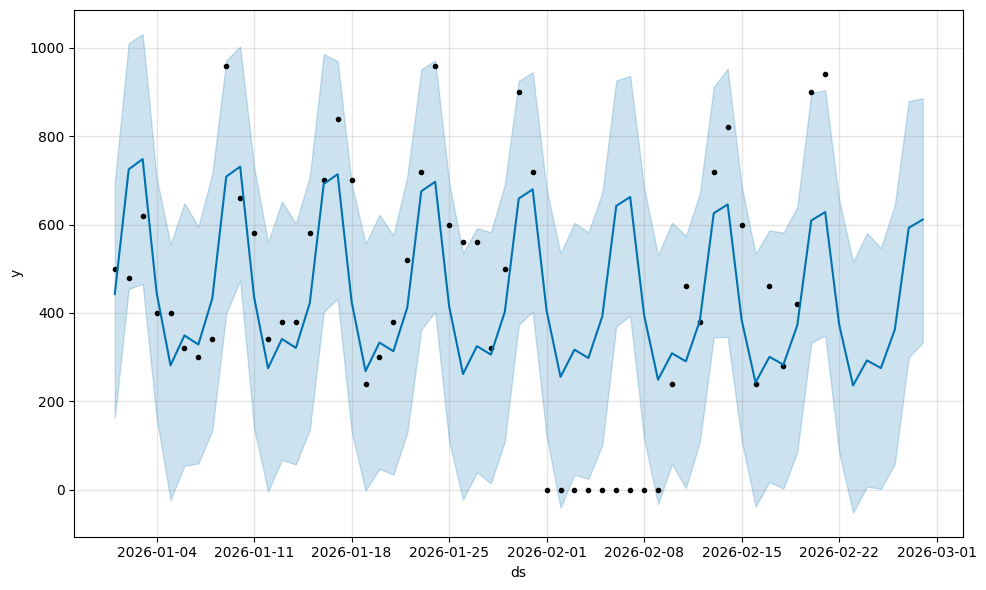

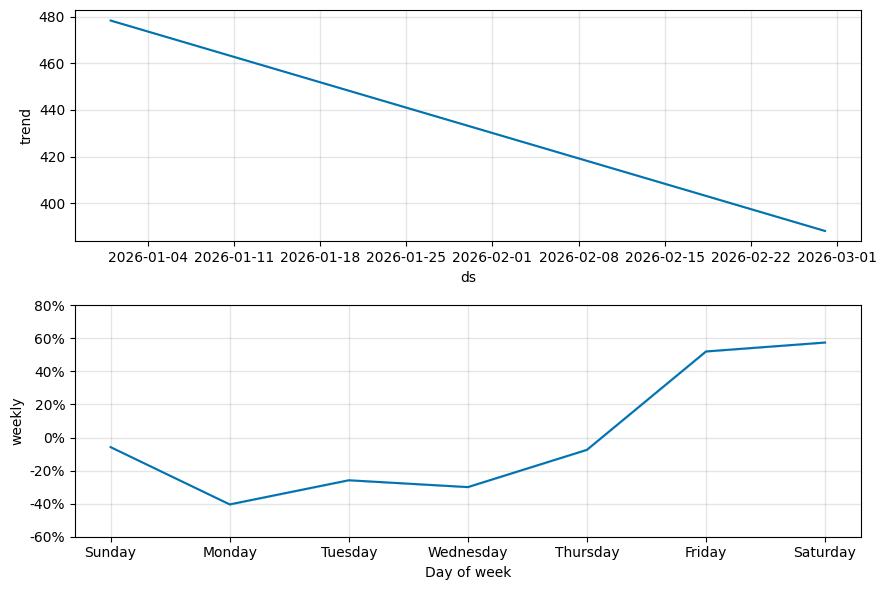

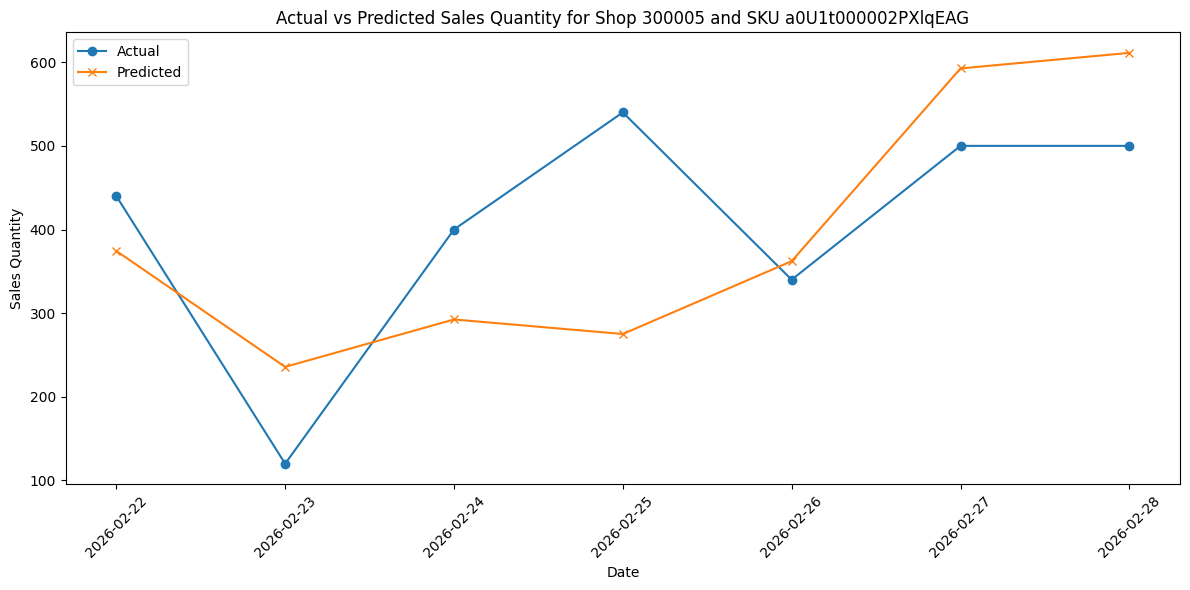


Processing Customer 301097 and SKU a0U1t000002PXlqEAG...


15:22:40 - cmdstanpy - INFO - Chain [1] start processing
15:22:40 - cmdstanpy - INFO - Chain [1] done processing
15:22:40 - cmdstanpy - INFO - Chain [1] start processing
15:22:40 - cmdstanpy - INFO - Chain [1] done processing
15:22:41 - cmdstanpy - INFO - Chain [1] start processing
15:22:41 - cmdstanpy - INFO - Chain [1] done processing
15:22:41 - cmdstanpy - INFO - Chain [1] start processing
15:22:41 - cmdstanpy - INFO - Chain [1] done processing
15:22:41 - cmdstanpy - INFO - Chain [1] start processing
15:22:41 - cmdstanpy - INFO - Chain [1] done processing
15:22:41 - cmdstanpy - INFO - Chain [1] start processing
15:22:41 - cmdstanpy - INFO - Chain [1] done processing
15:22:42 - cmdstanpy - INFO - Chain [1] start processing
15:22:42 - cmdstanpy - INFO - Chain [1] done processing
15:22:42 - cmdstanpy - INFO - Chain [1] start processing
15:22:42 - cmdstanpy - INFO - Chain [1] done processing
15:22:42 - cmdstanpy - INFO - Chain [1] start processing
15:22:43 - cmdstanpy - INFO - Chain [1]

Best Params: {'changepoint_prior_scale': 0.01, 'seasonality_prior_scale': 5.0, 'seasonality_mode': 'additive'}
Best RMSE: 113.39400293160001


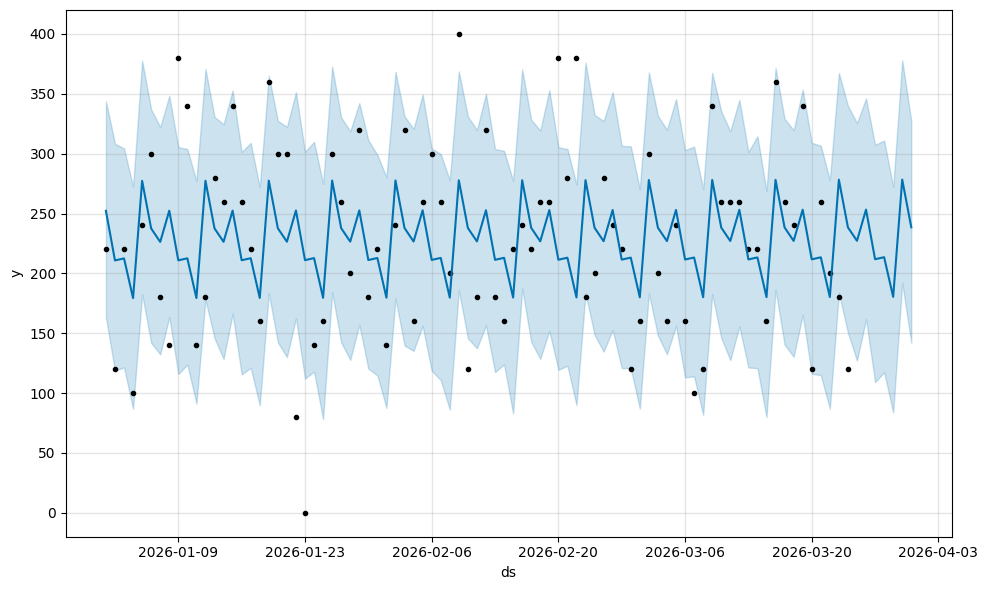

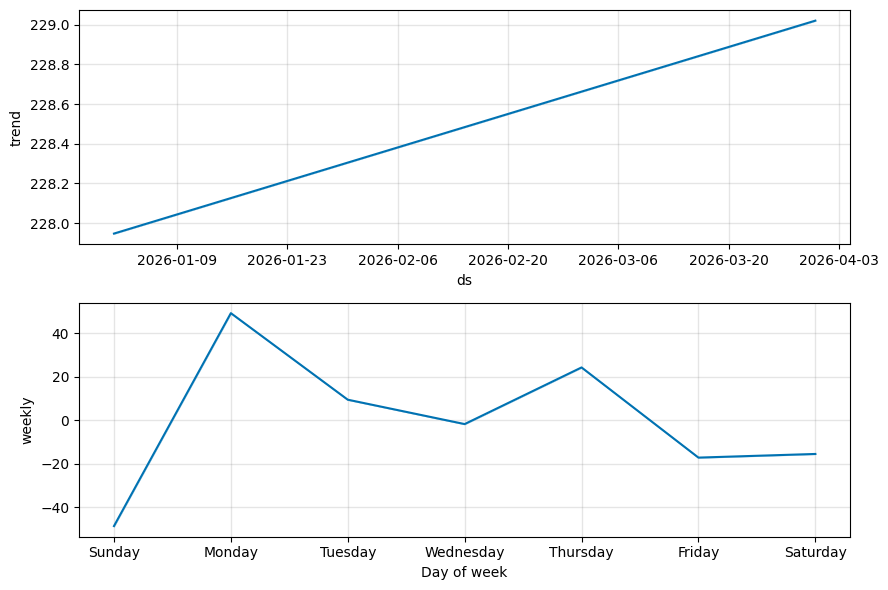

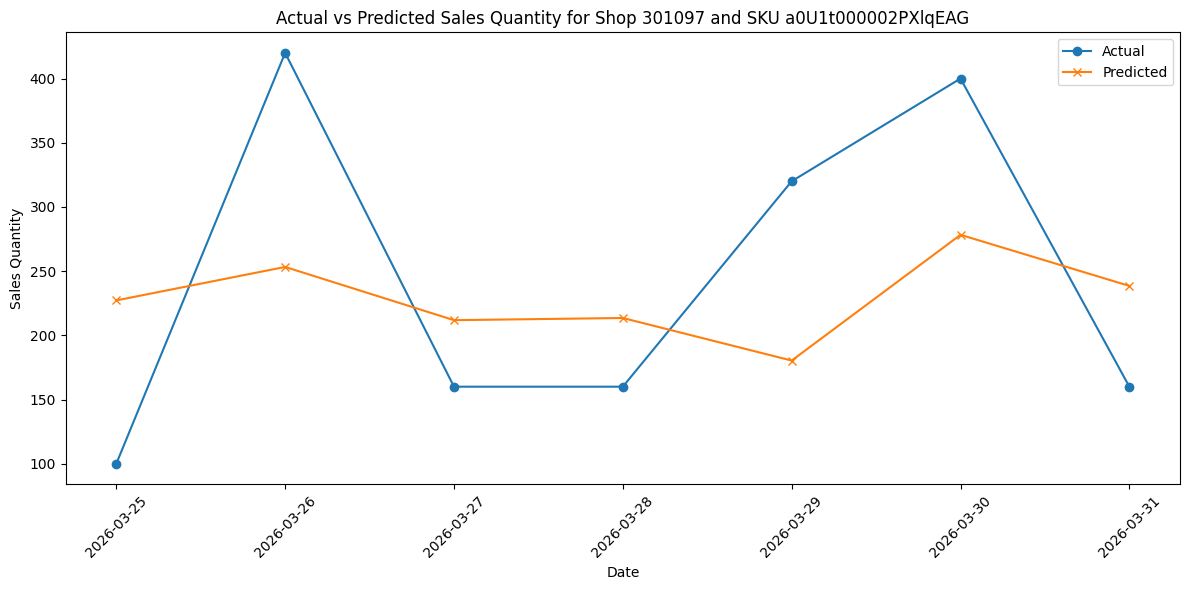


Processing Customer 302198 and SKU a0U1t000002PXlqEAG...


15:22:48 - cmdstanpy - INFO - Chain [1] start processing
15:22:48 - cmdstanpy - INFO - Chain [1] done processing
15:22:48 - cmdstanpy - INFO - Chain [1] start processing
15:22:49 - cmdstanpy - INFO - Chain [1] done processing
15:22:49 - cmdstanpy - INFO - Chain [1] start processing
15:22:49 - cmdstanpy - INFO - Chain [1] done processing
15:22:49 - cmdstanpy - INFO - Chain [1] start processing
15:22:49 - cmdstanpy - INFO - Chain [1] done processing
15:22:49 - cmdstanpy - INFO - Chain [1] start processing
15:22:49 - cmdstanpy - INFO - Chain [1] done processing
15:22:49 - cmdstanpy - INFO - Chain [1] start processing
15:22:50 - cmdstanpy - INFO - Chain [1] done processing
15:22:50 - cmdstanpy - INFO - Chain [1] start processing
15:22:50 - cmdstanpy - INFO - Chain [1] done processing
15:22:50 - cmdstanpy - INFO - Chain [1] start processing
15:22:51 - cmdstanpy - INFO - Chain [1] done processing
15:22:51 - cmdstanpy - INFO - Chain [1] start processing
15:22:51 - cmdstanpy - INFO - Chain [1]

Best Params: {'changepoint_prior_scale': 0.01, 'seasonality_prior_scale': 1.0, 'seasonality_mode': 'additive'}
Best RMSE: 101.2639649001875


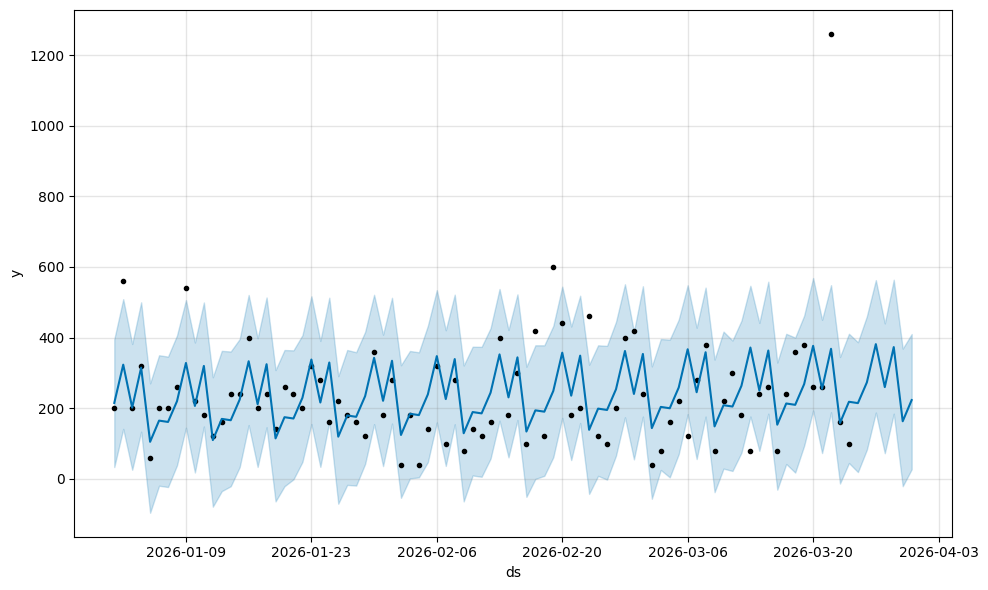

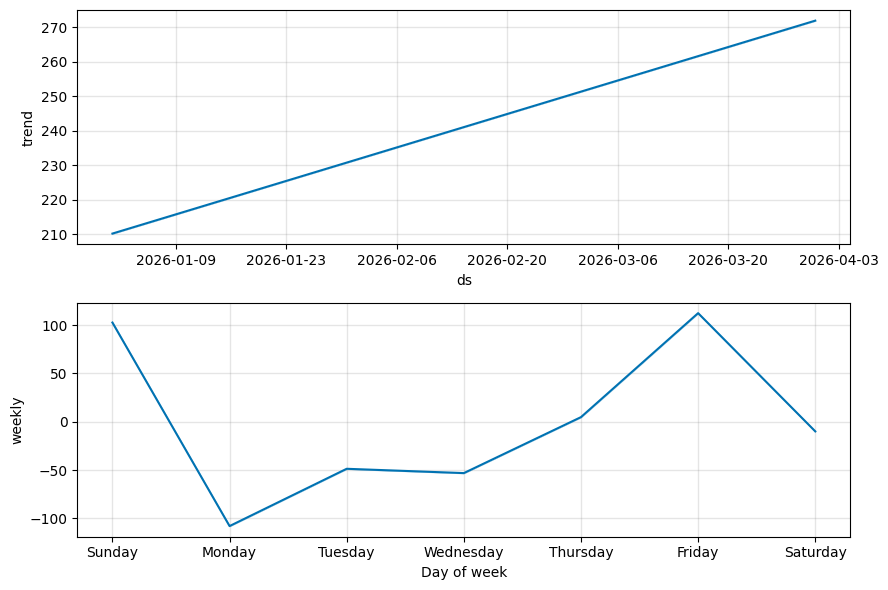

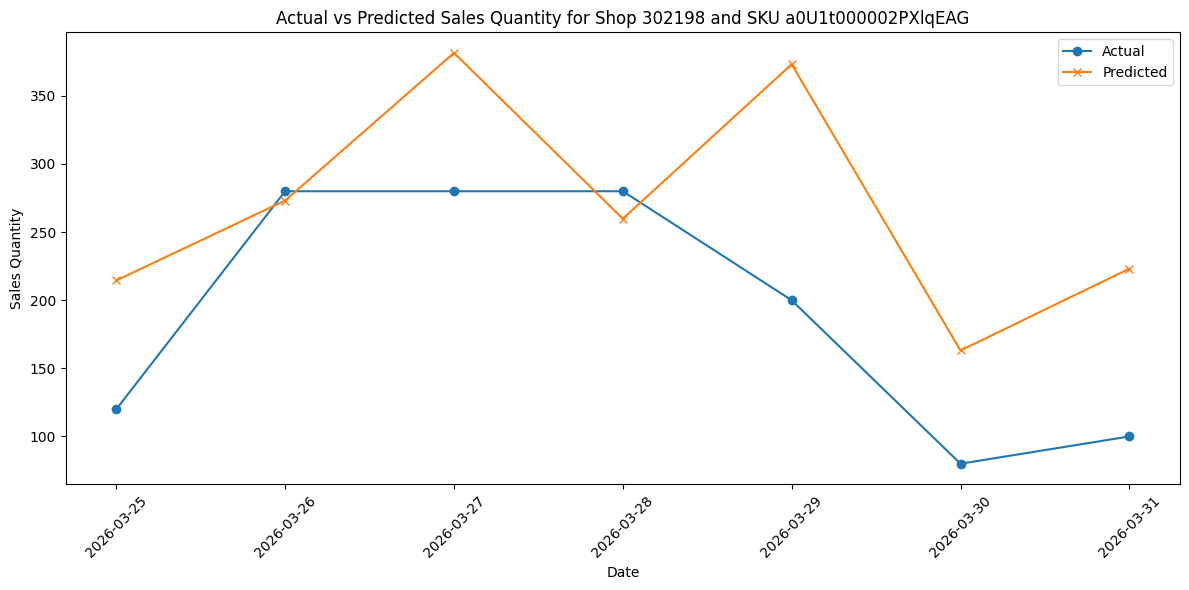


Processing Customer 304032 and SKU a0U1t000002PXlqEAG...


15:22:57 - cmdstanpy - INFO - Chain [1] start processing
15:22:57 - cmdstanpy - INFO - Chain [1] done processing
15:22:57 - cmdstanpy - INFO - Chain [1] start processing
15:22:58 - cmdstanpy - INFO - Chain [1] done processing
15:22:58 - cmdstanpy - INFO - Chain [1] start processing
15:22:59 - cmdstanpy - INFO - Chain [1] done processing
15:22:59 - cmdstanpy - INFO - Chain [1] start processing
15:22:59 - cmdstanpy - INFO - Chain [1] done processing
15:22:59 - cmdstanpy - INFO - Chain [1] start processing
15:22:59 - cmdstanpy - INFO - Chain [1] done processing
15:22:59 - cmdstanpy - INFO - Chain [1] start processing
15:23:00 - cmdstanpy - INFO - Chain [1] done processing
15:23:00 - cmdstanpy - INFO - Chain [1] start processing
15:23:00 - cmdstanpy - INFO - Chain [1] done processing
15:23:00 - cmdstanpy - INFO - Chain [1] start processing
15:23:00 - cmdstanpy - INFO - Chain [1] done processing
15:23:00 - cmdstanpy - INFO - Chain [1] start processing
15:23:00 - cmdstanpy - INFO - Chain [1]

Best Params: {'changepoint_prior_scale': 0.5, 'seasonality_prior_scale': 1.0, 'seasonality_mode': 'multiplicative'}
Best RMSE: 94.15540615026767


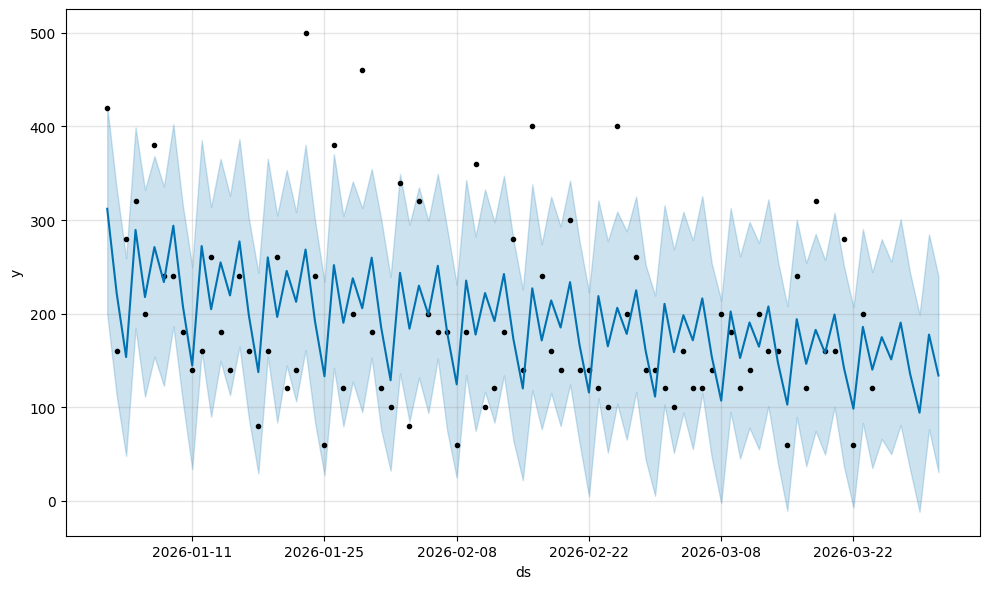

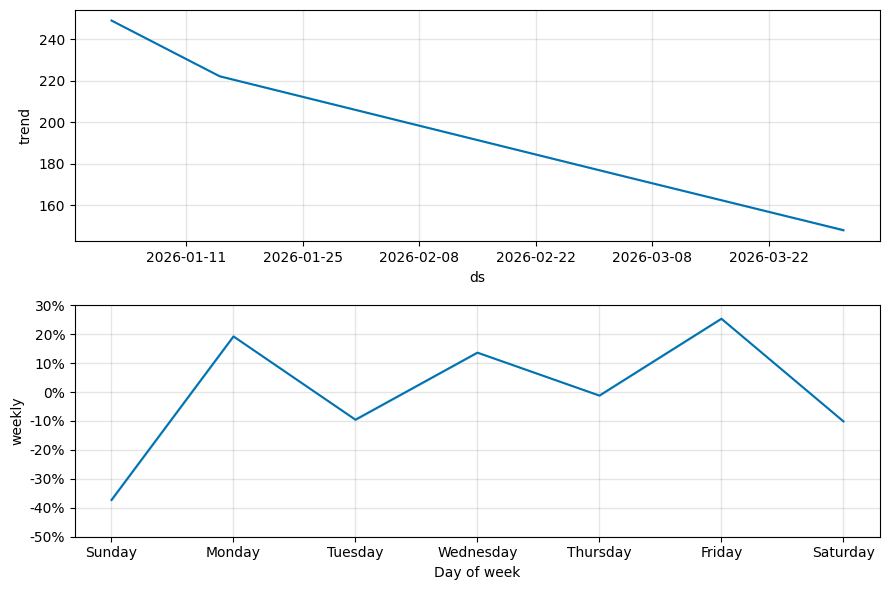

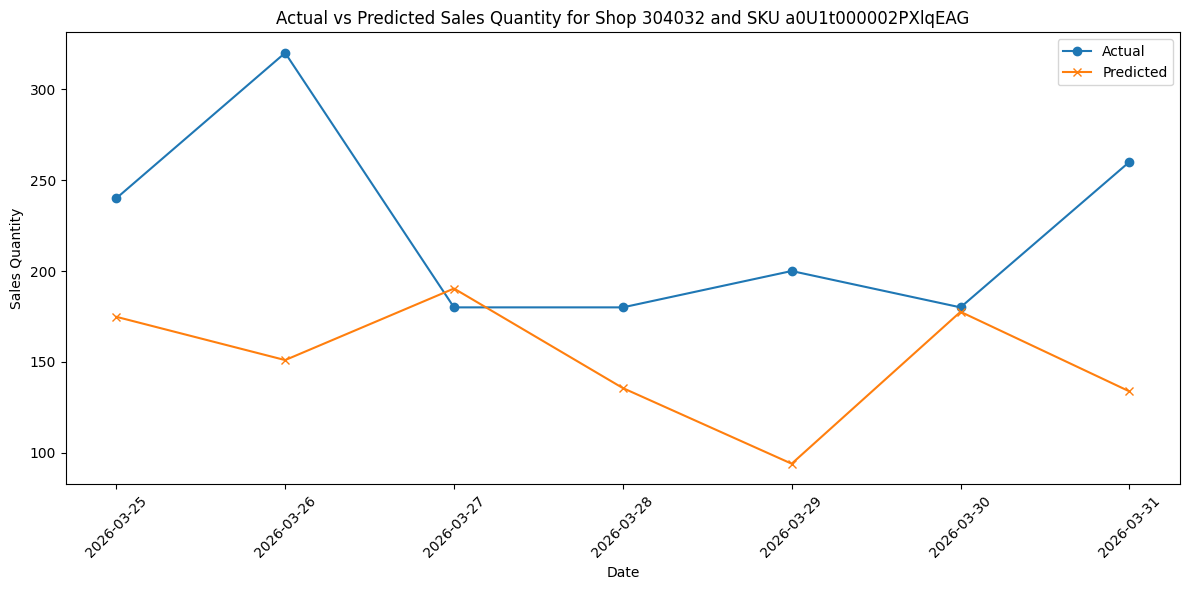

15:23:04 - cmdstanpy - INFO - Chain [1] start processing



Processing Customer 306055 and SKU a0U1t000002PXlqEAG...


15:23:04 - cmdstanpy - INFO - Chain [1] done processing
15:23:05 - cmdstanpy - INFO - Chain [1] start processing
15:23:05 - cmdstanpy - INFO - Chain [1] done processing
15:23:05 - cmdstanpy - INFO - Chain [1] start processing
15:23:05 - cmdstanpy - INFO - Chain [1] done processing
15:23:05 - cmdstanpy - INFO - Chain [1] start processing
15:23:05 - cmdstanpy - INFO - Chain [1] done processing
15:23:05 - cmdstanpy - INFO - Chain [1] start processing
15:23:05 - cmdstanpy - INFO - Chain [1] done processing
15:23:05 - cmdstanpy - INFO - Chain [1] start processing
15:23:06 - cmdstanpy - INFO - Chain [1] done processing
15:23:06 - cmdstanpy - INFO - Chain [1] start processing
15:23:06 - cmdstanpy - INFO - Chain [1] done processing
15:23:06 - cmdstanpy - INFO - Chain [1] start processing
15:23:06 - cmdstanpy - INFO - Chain [1] done processing
15:23:06 - cmdstanpy - INFO - Chain [1] start processing
15:23:07 - cmdstanpy - INFO - Chain [1] done processing
15:23:07 - cmdstanpy - INFO - Chain [1] 

Best Params: {'changepoint_prior_scale': 0.1, 'seasonality_prior_scale': 1.0, 'seasonality_mode': 'multiplicative'}
Best RMSE: 159.99735750696698


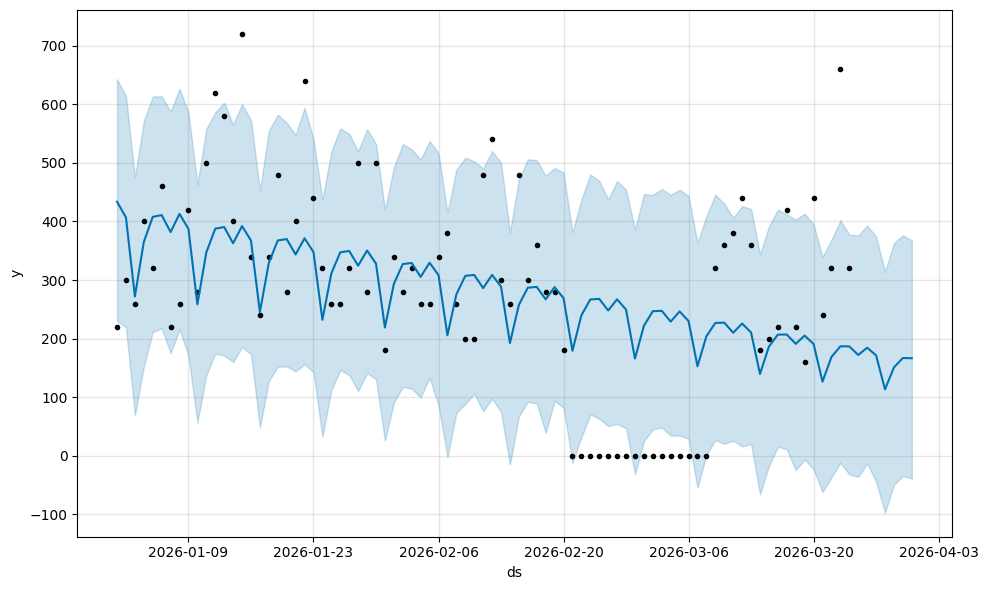

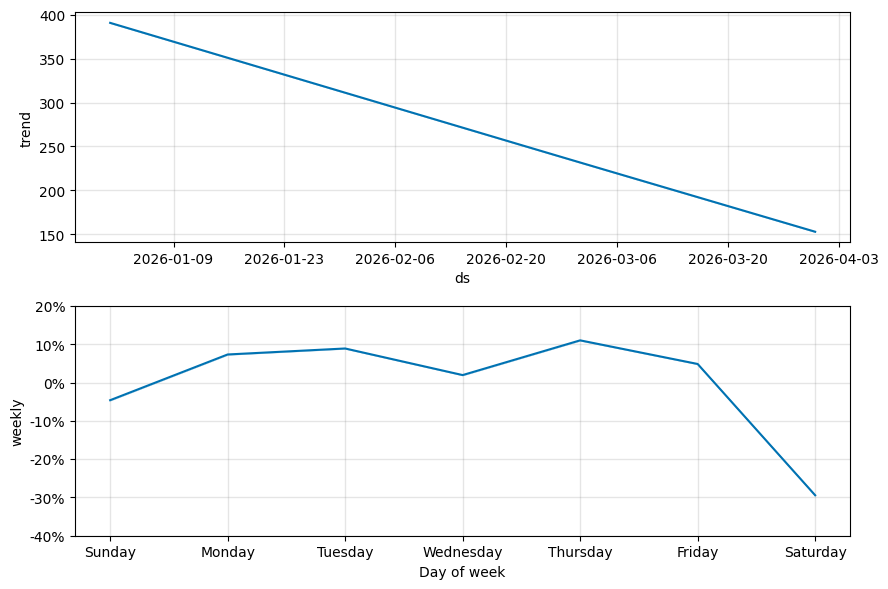

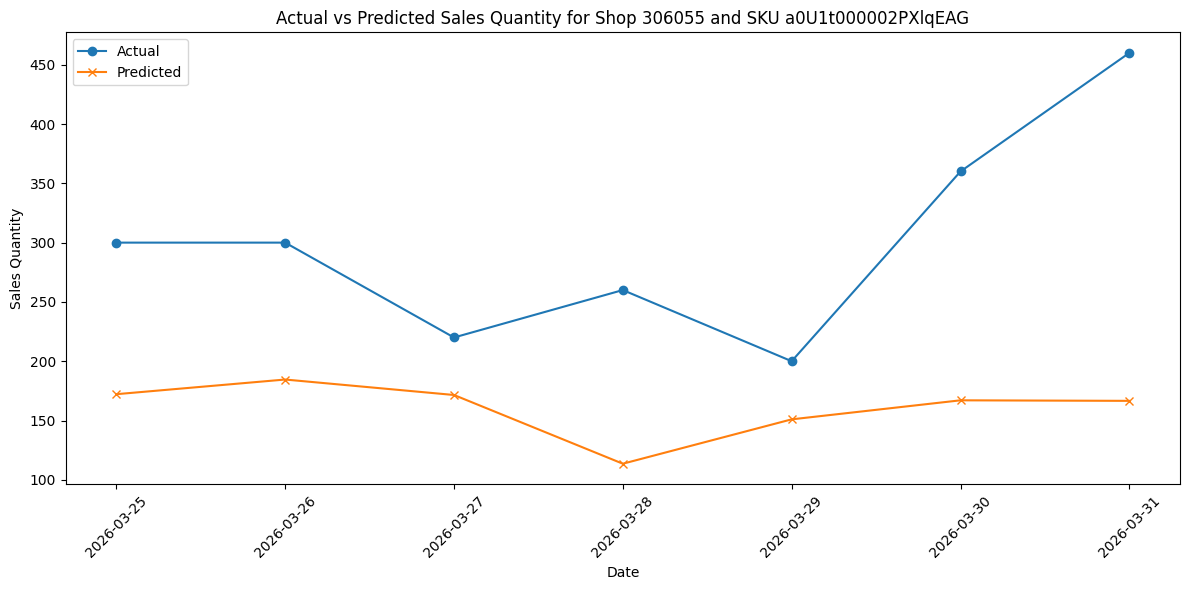

In [26]:
train(top_sku_per_customer, all_params)

### Prediction on Sale In Data 

In [28]:
df_path = "../../../../data/France/processed_data/sell_in_merged.csv"
df = pd.read_csv(df_path, low_memory=False)
df["date"] = pd.to_datetime(df["date"])

df = df[df["sku_code"] != 99999]

In [30]:
top_sku_per_customers_sell_in = top_n_customers_sku(df, top_n=5)


Processing Customer 300005 and SKU 3721...


15:26:27 - cmdstanpy - INFO - Chain [1] start processing
15:26:27 - cmdstanpy - INFO - Chain [1] done processing
15:26:27 - cmdstanpy - INFO - Chain [1] start processing
15:26:27 - cmdstanpy - INFO - Chain [1] done processing
15:26:27 - cmdstanpy - INFO - Chain [1] start processing
15:26:28 - cmdstanpy - INFO - Chain [1] done processing
15:26:28 - cmdstanpy - INFO - Chain [1] start processing
15:26:28 - cmdstanpy - INFO - Chain [1] done processing
15:26:28 - cmdstanpy - INFO - Chain [1] start processing
15:26:28 - cmdstanpy - INFO - Chain [1] done processing
15:26:28 - cmdstanpy - INFO - Chain [1] start processing
15:26:28 - cmdstanpy - INFO - Chain [1] done processing
15:26:28 - cmdstanpy - INFO - Chain [1] start processing
15:26:29 - cmdstanpy - INFO - Chain [1] done processing
15:26:29 - cmdstanpy - INFO - Chain [1] start processing
15:26:29 - cmdstanpy - INFO - Chain [1] done processing
15:26:29 - cmdstanpy - INFO - Chain [1] start processing
15:26:30 - cmdstanpy - INFO - Chain [1]

Best Params: {'changepoint_prior_scale': 0.1, 'seasonality_prior_scale': 5.0, 'seasonality_mode': 'multiplicative'}
Best RMSE: 415.6711572382951


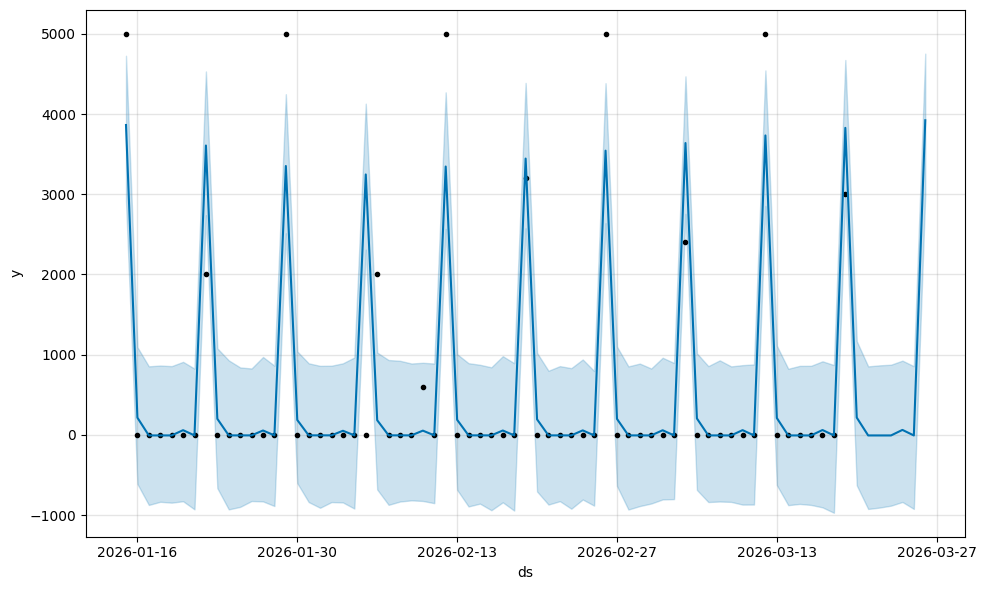

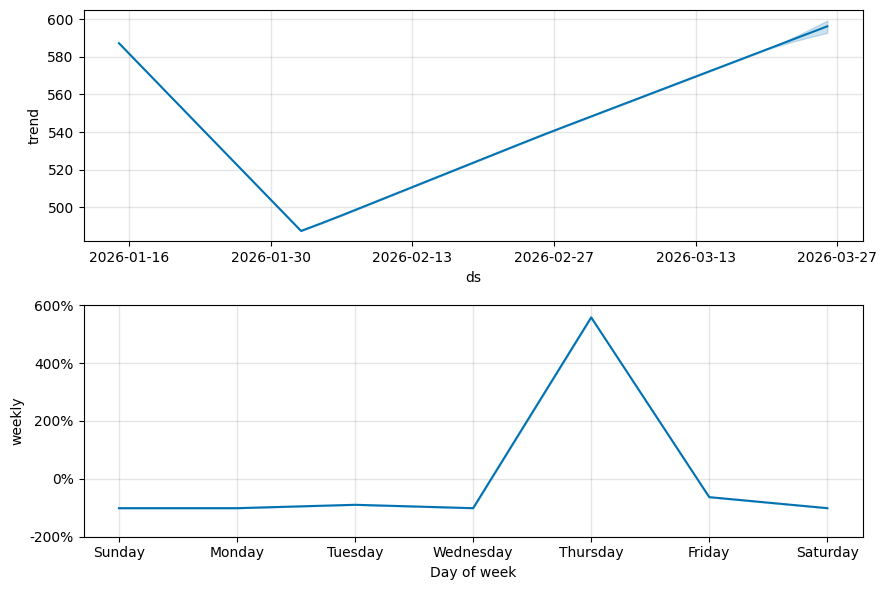

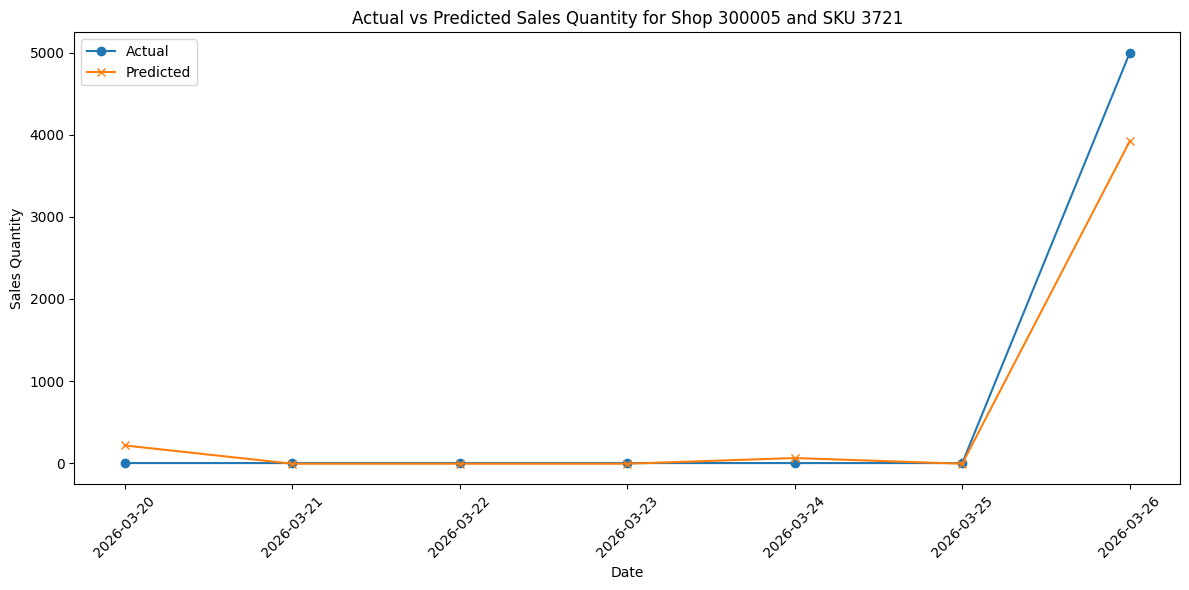

15:26:37 - cmdstanpy - INFO - Chain [1] start processing
15:26:37 - cmdstanpy - INFO - Chain [1] done processing



Processing Customer 302153 and SKU 3721...


15:26:37 - cmdstanpy - INFO - Chain [1] start processing
15:26:38 - cmdstanpy - INFO - Chain [1] done processing
15:26:38 - cmdstanpy - INFO - Chain [1] start processing
15:26:38 - cmdstanpy - INFO - Chain [1] done processing
15:26:38 - cmdstanpy - INFO - Chain [1] start processing
15:26:38 - cmdstanpy - INFO - Chain [1] done processing
15:26:38 - cmdstanpy - INFO - Chain [1] start processing
15:26:38 - cmdstanpy - INFO - Chain [1] done processing
15:26:38 - cmdstanpy - INFO - Chain [1] start processing
15:26:38 - cmdstanpy - INFO - Chain [1] done processing
15:26:38 - cmdstanpy - INFO - Chain [1] start processing
15:26:39 - cmdstanpy - INFO - Chain [1] done processing
15:26:39 - cmdstanpy - INFO - Chain [1] start processing
15:26:39 - cmdstanpy - INFO - Chain [1] done processing
15:26:39 - cmdstanpy - INFO - Chain [1] start processing
15:26:39 - cmdstanpy - INFO - Chain [1] done processing
15:26:39 - cmdstanpy - INFO - Chain [1] start processing
15:26:40 - cmdstanpy - INFO - Chain [1]

Best Params: {'changepoint_prior_scale': 0.5, 'seasonality_prior_scale': 10.0, 'seasonality_mode': 'additive'}
Best RMSE: 1469.9320300816155


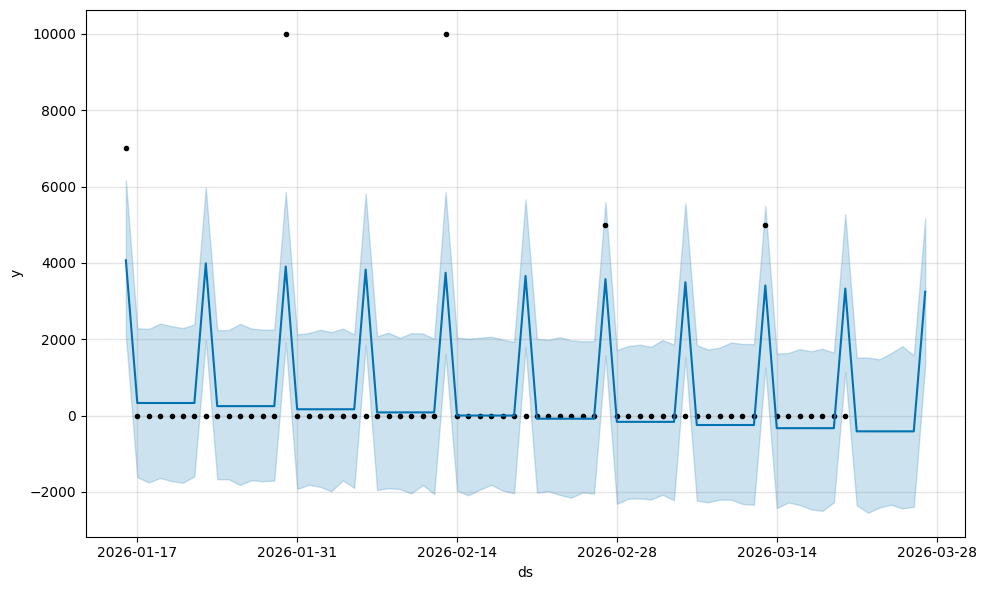

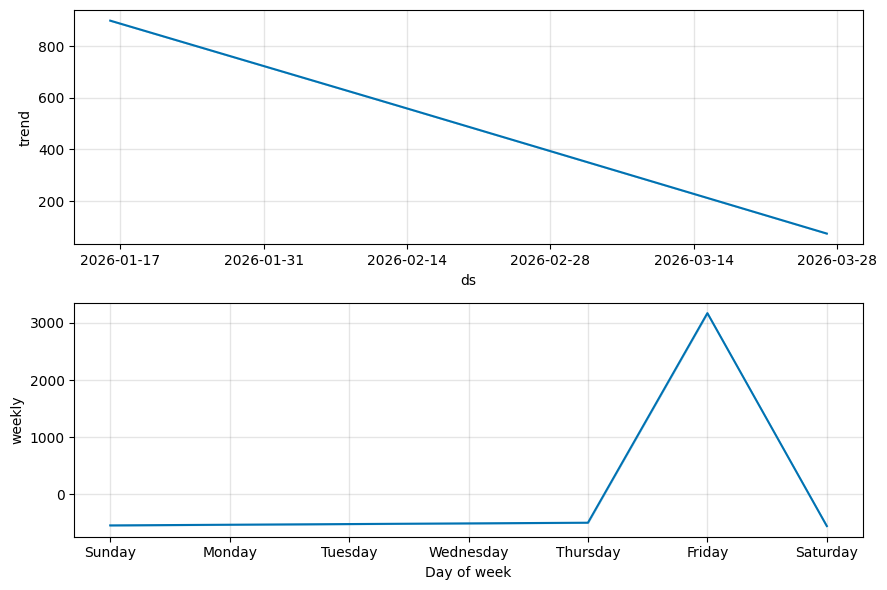

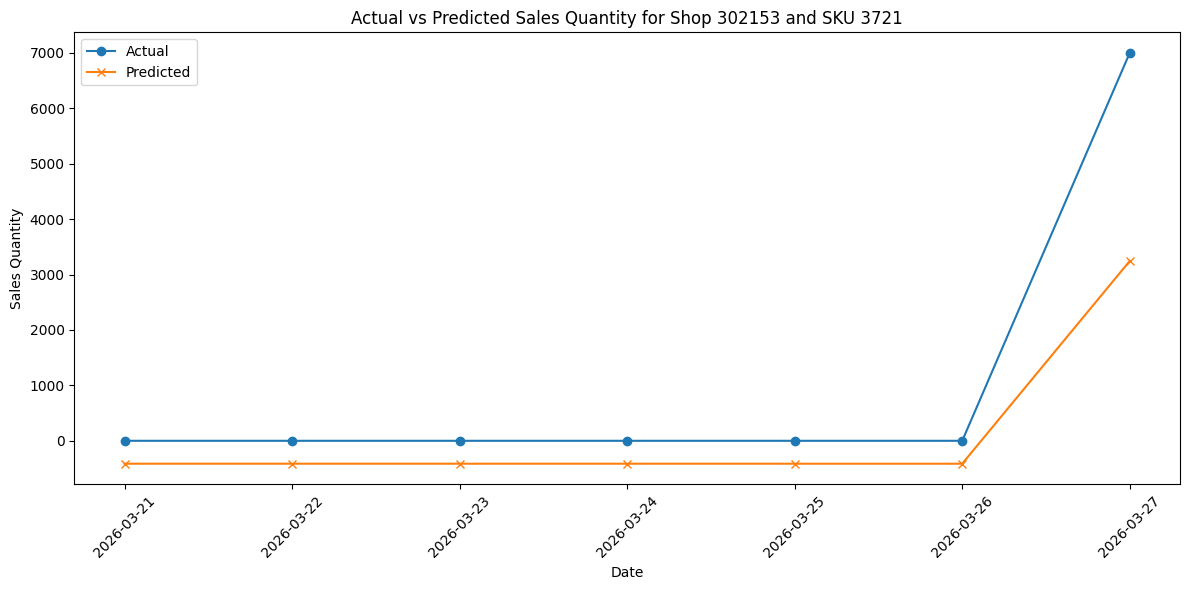

15:27:46 - cmdstanpy - INFO - Chain [1] start processing
15:27:46 - cmdstanpy - INFO - Chain [1] done processing



Processing Customer 302198 and SKU 85548...


15:27:46 - cmdstanpy - INFO - Chain [1] start processing
15:27:46 - cmdstanpy - INFO - Chain [1] done processing
15:27:46 - cmdstanpy - INFO - Chain [1] start processing
15:27:47 - cmdstanpy - INFO - Chain [1] done processing
15:27:47 - cmdstanpy - INFO - Chain [1] start processing
15:27:47 - cmdstanpy - INFO - Chain [1] done processing
15:27:47 - cmdstanpy - INFO - Chain [1] start processing
15:27:47 - cmdstanpy - INFO - Chain [1] done processing
15:27:47 - cmdstanpy - INFO - Chain [1] start processing
15:27:47 - cmdstanpy - INFO - Chain [1] done processing
15:27:48 - cmdstanpy - INFO - Chain [1] start processing
15:27:48 - cmdstanpy - INFO - Chain [1] done processing
15:27:48 - cmdstanpy - INFO - Chain [1] start processing
15:27:48 - cmdstanpy - INFO - Chain [1] done processing
15:27:48 - cmdstanpy - INFO - Chain [1] start processing
15:27:49 - cmdstanpy - INFO - Chain [1] done processing
15:27:49 - cmdstanpy - INFO - Chain [1] start processing
15:27:49 - cmdstanpy - INFO - Chain [1]

Best Params: {'changepoint_prior_scale': 0.1, 'seasonality_prior_scale': 1.0, 'seasonality_mode': 'additive'}
Best RMSE: 4747.4536260672085


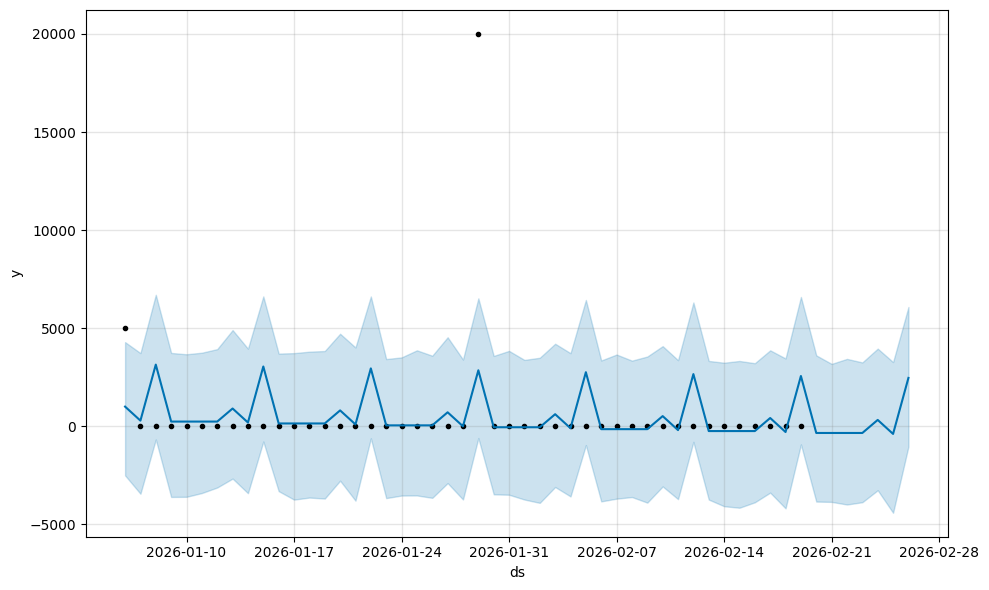

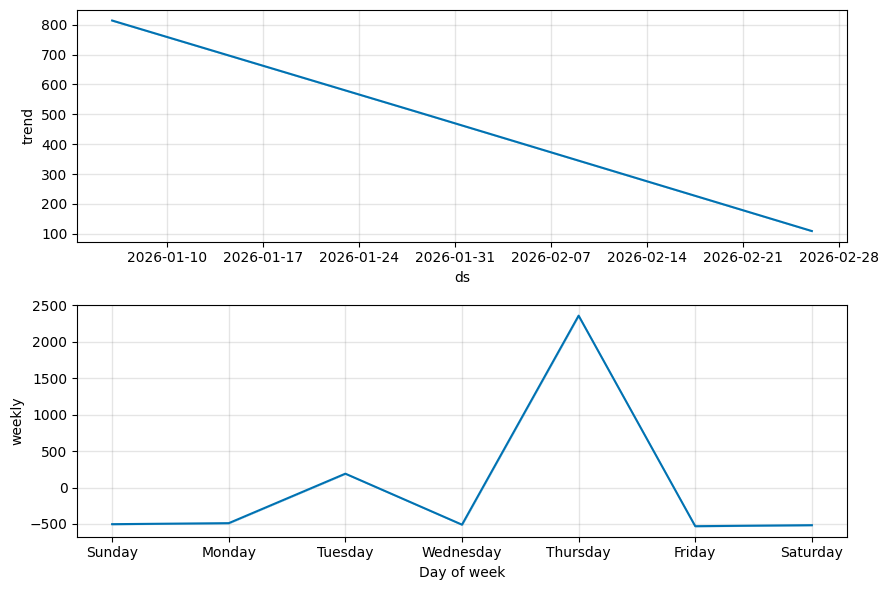

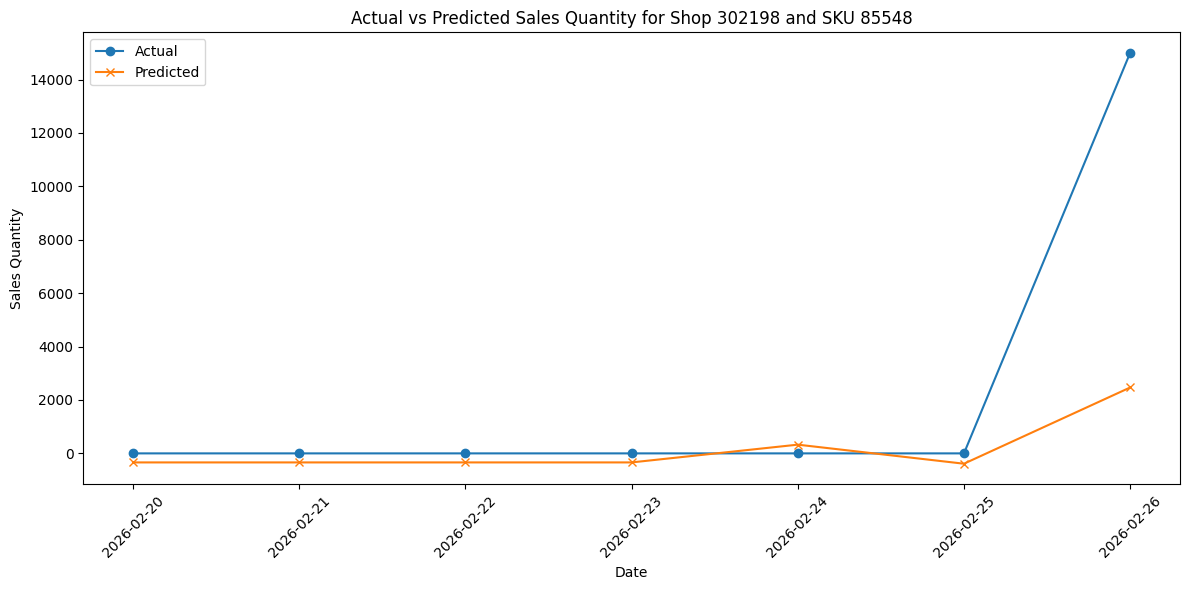

15:28:28 - cmdstanpy - INFO - Chain [1] start processing



Processing Customer 306009 and SKU 85548...


15:28:28 - cmdstanpy - INFO - Chain [1] done processing
15:28:28 - cmdstanpy - INFO - Chain [1] start processing
15:28:28 - cmdstanpy - INFO - Chain [1] done processing
15:28:29 - cmdstanpy - INFO - Chain [1] start processing
15:28:29 - cmdstanpy - INFO - Chain [1] done processing
15:28:29 - cmdstanpy - INFO - Chain [1] start processing
15:28:29 - cmdstanpy - INFO - Chain [1] done processing
15:28:29 - cmdstanpy - INFO - Chain [1] start processing
15:28:29 - cmdstanpy - INFO - Chain [1] done processing
15:28:29 - cmdstanpy - INFO - Chain [1] start processing
15:28:29 - cmdstanpy - INFO - Chain [1] done processing
15:28:29 - cmdstanpy - INFO - Chain [1] start processing
15:28:29 - cmdstanpy - INFO - Chain [1] done processing
15:28:30 - cmdstanpy - INFO - Chain [1] start processing
15:28:30 - cmdstanpy - INFO - Chain [1] done processing
15:28:30 - cmdstanpy - INFO - Chain [1] start processing
15:28:30 - cmdstanpy - INFO - Chain [1] done processing
15:28:30 - cmdstanpy - INFO - Chain [1] 

Best Params: {'changepoint_prior_scale': 0.1, 'seasonality_prior_scale': 5.0, 'seasonality_mode': 'multiplicative'}
Best RMSE: 142.676853115639


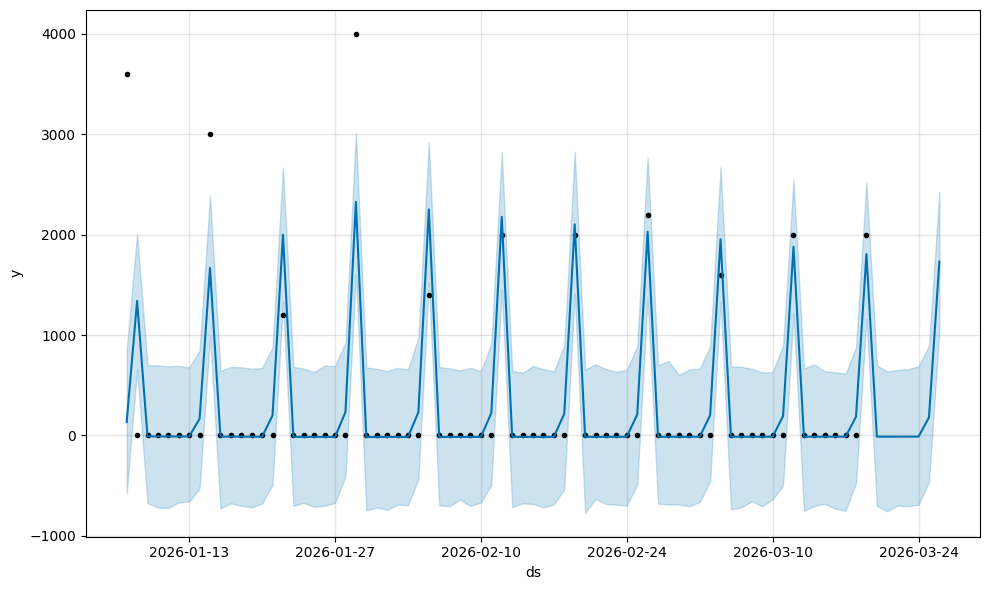

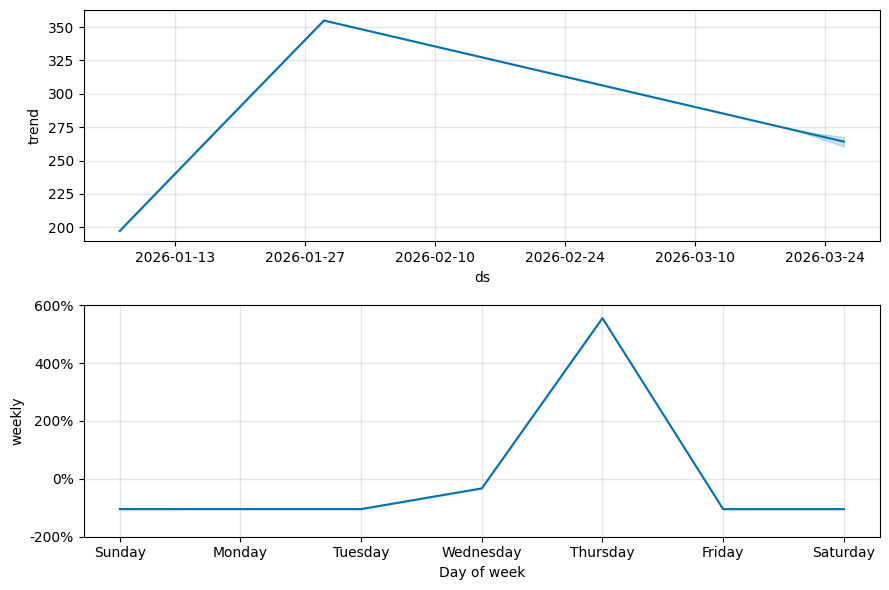

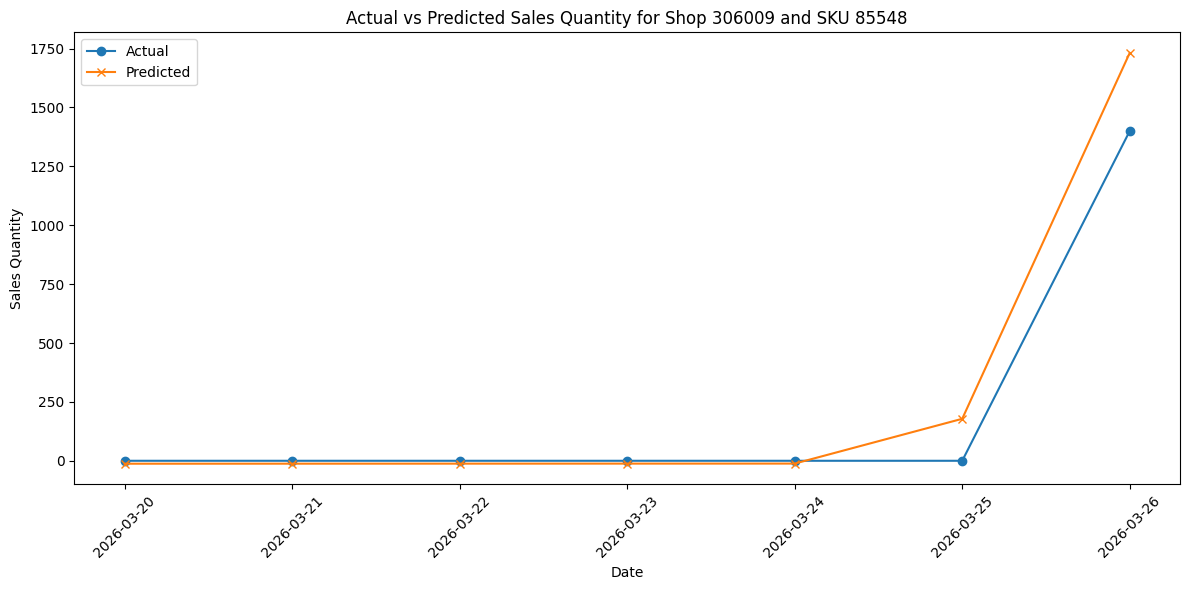

15:28:37 - cmdstanpy - INFO - Chain [1] start processing
15:28:37 - cmdstanpy - INFO - Chain [1] done processing



Processing Customer 309176 and SKU 3721...


15:28:37 - cmdstanpy - INFO - Chain [1] start processing
15:28:37 - cmdstanpy - INFO - Chain [1] done processing
15:28:38 - cmdstanpy - INFO - Chain [1] start processing
15:28:38 - cmdstanpy - INFO - Chain [1] done processing
15:28:38 - cmdstanpy - INFO - Chain [1] start processing
15:28:38 - cmdstanpy - INFO - Chain [1] done processing
15:28:38 - cmdstanpy - INFO - Chain [1] start processing
15:28:38 - cmdstanpy - INFO - Chain [1] done processing
15:28:38 - cmdstanpy - INFO - Chain [1] start processing
15:28:38 - cmdstanpy - INFO - Chain [1] done processing
15:28:38 - cmdstanpy - INFO - Chain [1] start processing
15:28:39 - cmdstanpy - INFO - Chain [1] done processing
15:28:39 - cmdstanpy - INFO - Chain [1] start processing
15:28:39 - cmdstanpy - INFO - Chain [1] done processing
15:28:39 - cmdstanpy - INFO - Chain [1] start processing
15:28:39 - cmdstanpy - INFO - Chain [1] done processing
15:28:39 - cmdstanpy - INFO - Chain [1] start processing
15:28:40 - cmdstanpy - INFO - Chain [1]

Best Params: {'changepoint_prior_scale': 0.1, 'seasonality_prior_scale': 10.0, 'seasonality_mode': 'additive'}
Best RMSE: 1949.9960997153653


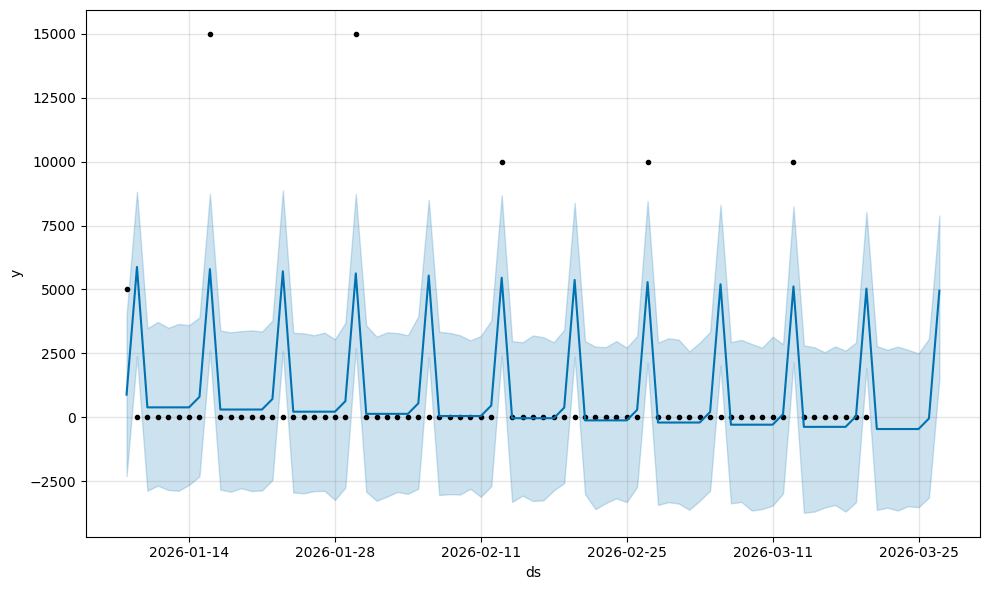

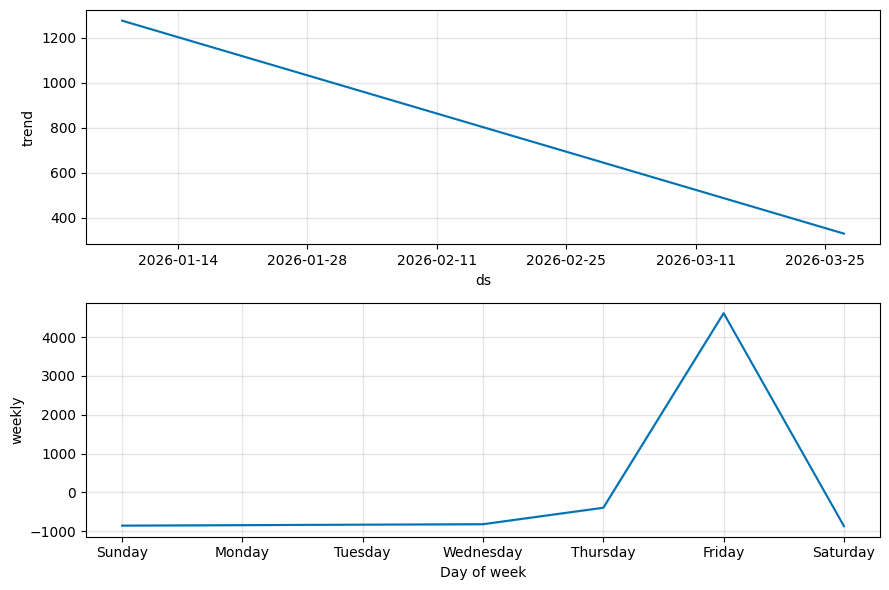

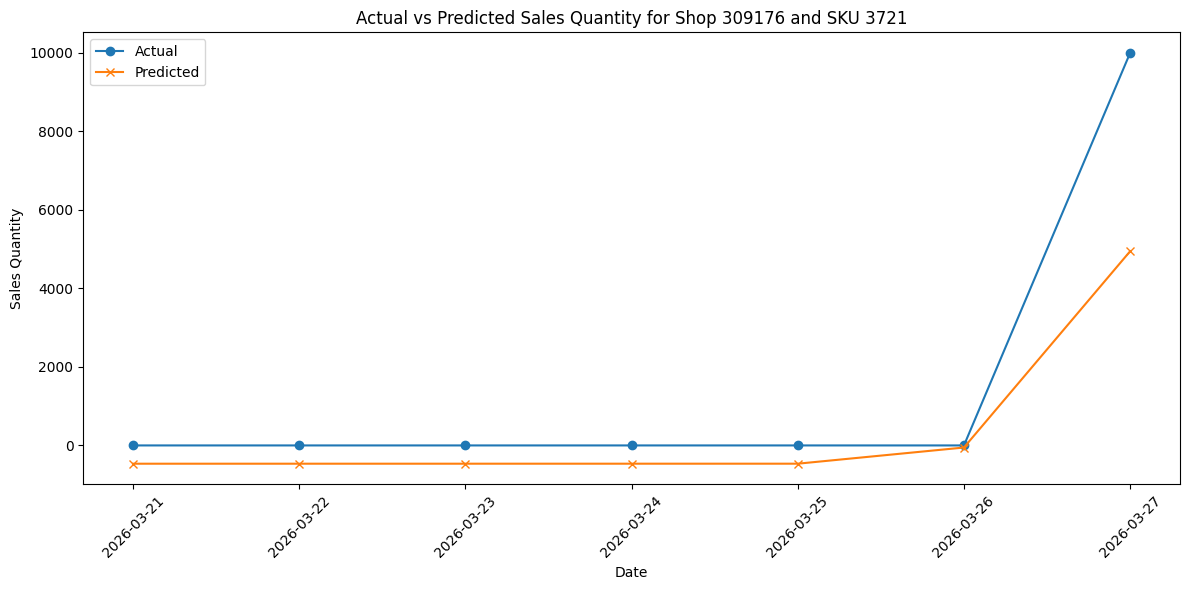

In [31]:
train(top_sku_per_customers_sell_in, all_params)